In [1]:
import os
import sys
from pathlib import Path
from src.prometheus_io import prom_query_range, prom_query_instant, test_connection
import src.prometheus_io as pio
from datetime import datetime, timezone, timedelta
import matplotlib.pyplot as plt

In [2]:
PROMETHEUS_URL = "http://178.104.69.73:9090"
TIME_WINDOW_HOURS = 1
END = datetime.now(timezone.utc)
START = END - timedelta(hours=TIME_WINDOW_HOURS)
STEP = '5s'
JOB = "chat-monolith"

In [3]:
connection_status = test_connection(PROMETHEUS_URL)
print('Connected: {}'.format(connection_status))

Connected: True


In [4]:
proc_cpu = prom_query_range(
    f'process_cpu_usage{{job="{JOB}"}}',
    START,
    END,
    STEP,
    base_url=PROMETHEUS_URL,
)
ws_active_sessions = prom_query_range(
    f'chat_ws_active_sessions{{job="{JOB}"}}',
    START,
    END,
    STEP,
    base_url=PROMETHEUS_URL,
)
ws_users = prom_query_range(
    f'chat_ws_active_users{{job="{JOB}"}}',
    START,
    END,
    STEP,
    base_url=PROMETHEUS_URL,
)
vus_http_senders = prom_query_range(
    'sum(k6_scenario_active_vus{scenario="http_senders"})',
    START,
    END,
    STEP,
    base_url=PROMETHEUS_URL,
)
vus_ws_receivers = prom_query_range(
    'sum(k6_scenario_active_vus{scenario="ws_receivers"})',
    START,
    END,
    STEP,
    base_url=PROMETHEUS_URL,
)

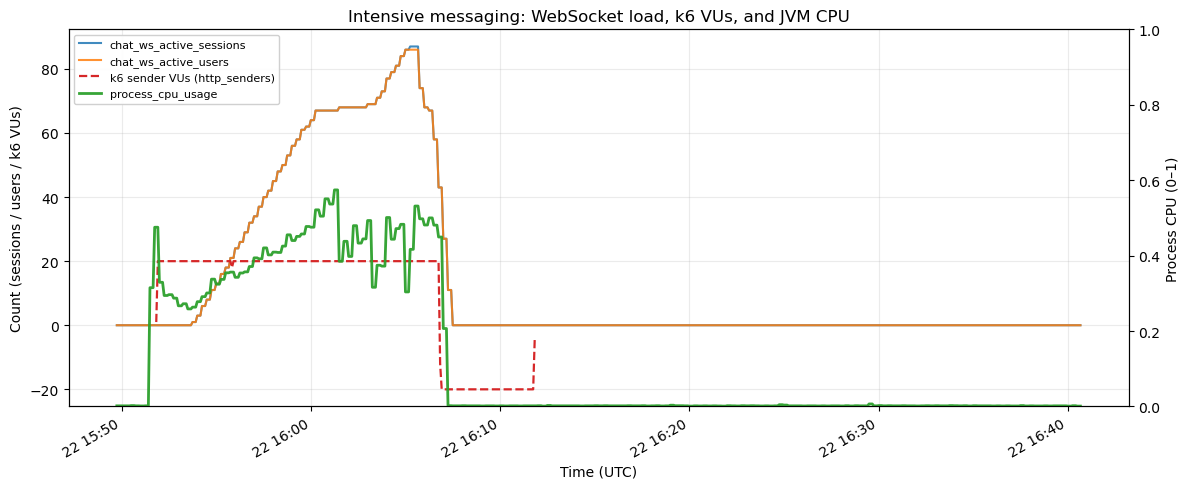

In [5]:
# Left: server metrics + k6 VUs (senders ~flat, receivers ramp) | Right: CPU
fig, ax1 = plt.subplots(figsize=(12, 5))

if not ws_active_sessions.empty:
    ws_active_sessions.iloc[:, 0].plot(ax=ax1, color="tab:blue", label="chat_ws_active_sessions", alpha=0.85)
    
if not ws_users.empty:
    ws_users.iloc[:, 0].plot(ax=ax1, color="tab:orange", label="chat_ws_active_users", alpha=0.85)
    
if not vus_http_senders.empty:
    vus_http_senders.iloc[:, 0].plot(
        ax=ax1, color="tab:red", linestyle="--", linewidth=1.6, label="k6 sender VUs (http_senders)"
    )

ax1.set_xlabel("Time (UTC)")
ax1.set_ylabel("Count (sessions / users / k6 VUs)")
ax1.set_title("Intensive messaging: WebSocket load, k6 VUs, and JVM CPU")
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
if not proc_cpu.empty:
    proc_cpu.iloc[:, 0].plot(ax=ax2, color="tab:green", label="process_cpu_usage", linewidth=2.0, alpha=0.95)
ax2.set_ylabel("Process CPU (0–1)")
ax2.set_ylim(0, 1)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", framealpha=0.92, fontsize=8)

fig.tight_layout()
plt.show()